# Phase 2 — Dataset Exploration

Exploring the merged, split, and augmented FFF 3D printing defect dataset.
Compares our independently collected dataset against the base paper's
original dataset.

In [1]:
import json
import yaml
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONFIG_PATH = PROJECT_ROOT / "configs" / "dataset_config.yaml"

with open(CONFIG_PATH) as f:
    dataset_config = yaml.safe_load(f)

print("Classes:", dataset_config["dataset"]["classes"])

Classes: ['Cracking', 'Layer_shifting', 'Off_platform', 'Stringing', 'Warping']


## Dataset size and split ratio

In [2]:
split_data = {}
for split in ["train", "val", "test"]:
    json_path = PROCESSED_DIR / split / "_annotations.coco.json"
    with open(json_path) as f:
        split_data[split] = json.load(f)

total_images = sum(len(d["images"]) for d in split_data.values())

print(f"{'Split':<10}{'Images':<10}{'Annotations':<14}{'% of total':<12}")
for split, data in split_data.items():
    n_img = len(data["images"])
    n_ann = len(data["annotations"])
    pct = n_img / total_images * 100
    print(f"{split:<10}{n_img:<10}{n_ann:<14}{pct:<12.1f}")

print(f"\nTotal images: {total_images}")

Split     Images    Annotations   % of total  
train     1532      2192          80.1        
val       185       262           9.7         
test      195       293           10.2        

Total images: 1912


## Class distribution per split

Our raw dataset (1867 images: Cracking=427, Layer_shifting=364,
Off_platform=91, Stringing=447, Warping=538) is substantially larger
and differently balanced than the base paper's original dataset
(294 images: Cracking=54, Layer_shifting=50, Off_platform=60,
Stringing=58, Warping=72). This is an independently collected dataset
covering the same 5 defect categories, not the paper's original data.

C:\Users\amirb\AppData\Local\Temp\ipykernel_17436\1550584359.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(classes_sorted, rotation=45, ha="right")
C:\Users\amirb\AppData\Local\Temp\ipykernel_17436\1550584359.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(classes_sorted, rotation=45, ha="right")
C:\Users\amirb\AppData\Local\Temp\ipykernel_17436\1550584359.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(classes_sorted, rotation=45, ha="right")


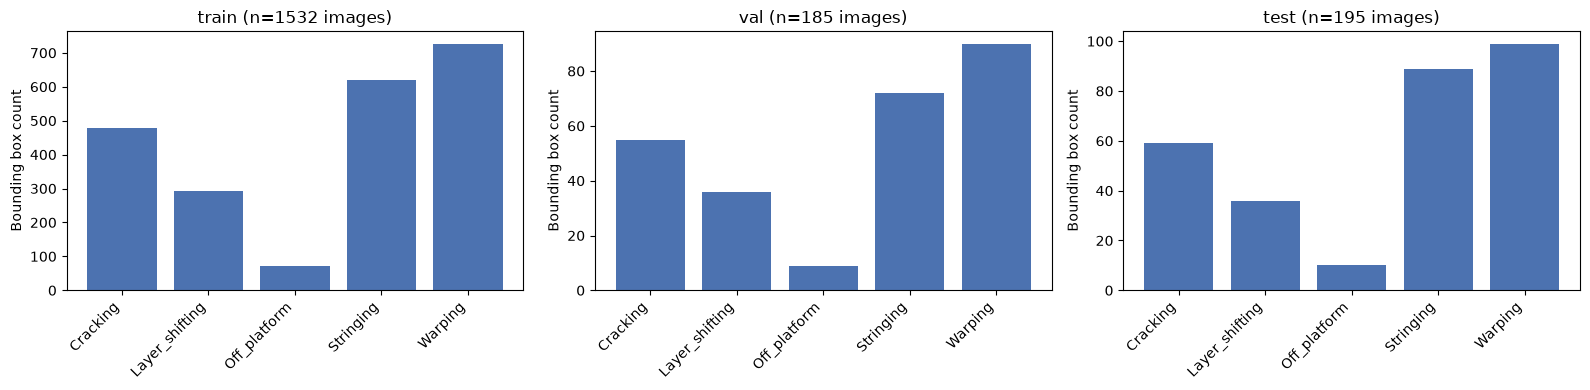

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (split, data) in zip(axes, split_data.items()):
    cat_id_to_name = {c["id"]: c["name"] for c in data["categories"]}
    counts = Counter(cat_id_to_name[ann["category_id"]] for ann in data["annotations"])

    classes_sorted = dataset_config["dataset"]["classes"]
    values = [counts.get(c, 0) for c in classes_sorted]

    ax.bar(classes_sorted, values, color="#4C72B0")
    ax.set_title(f"{split} (n={len(data['images'])} images)")
    ax.set_xticklabels(classes_sorted, rotation=45, ha="right")
    ax.set_ylabel("Bounding box count")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "class_distribution.png", dpi=150)
plt.show()

## Random annotated sample grid

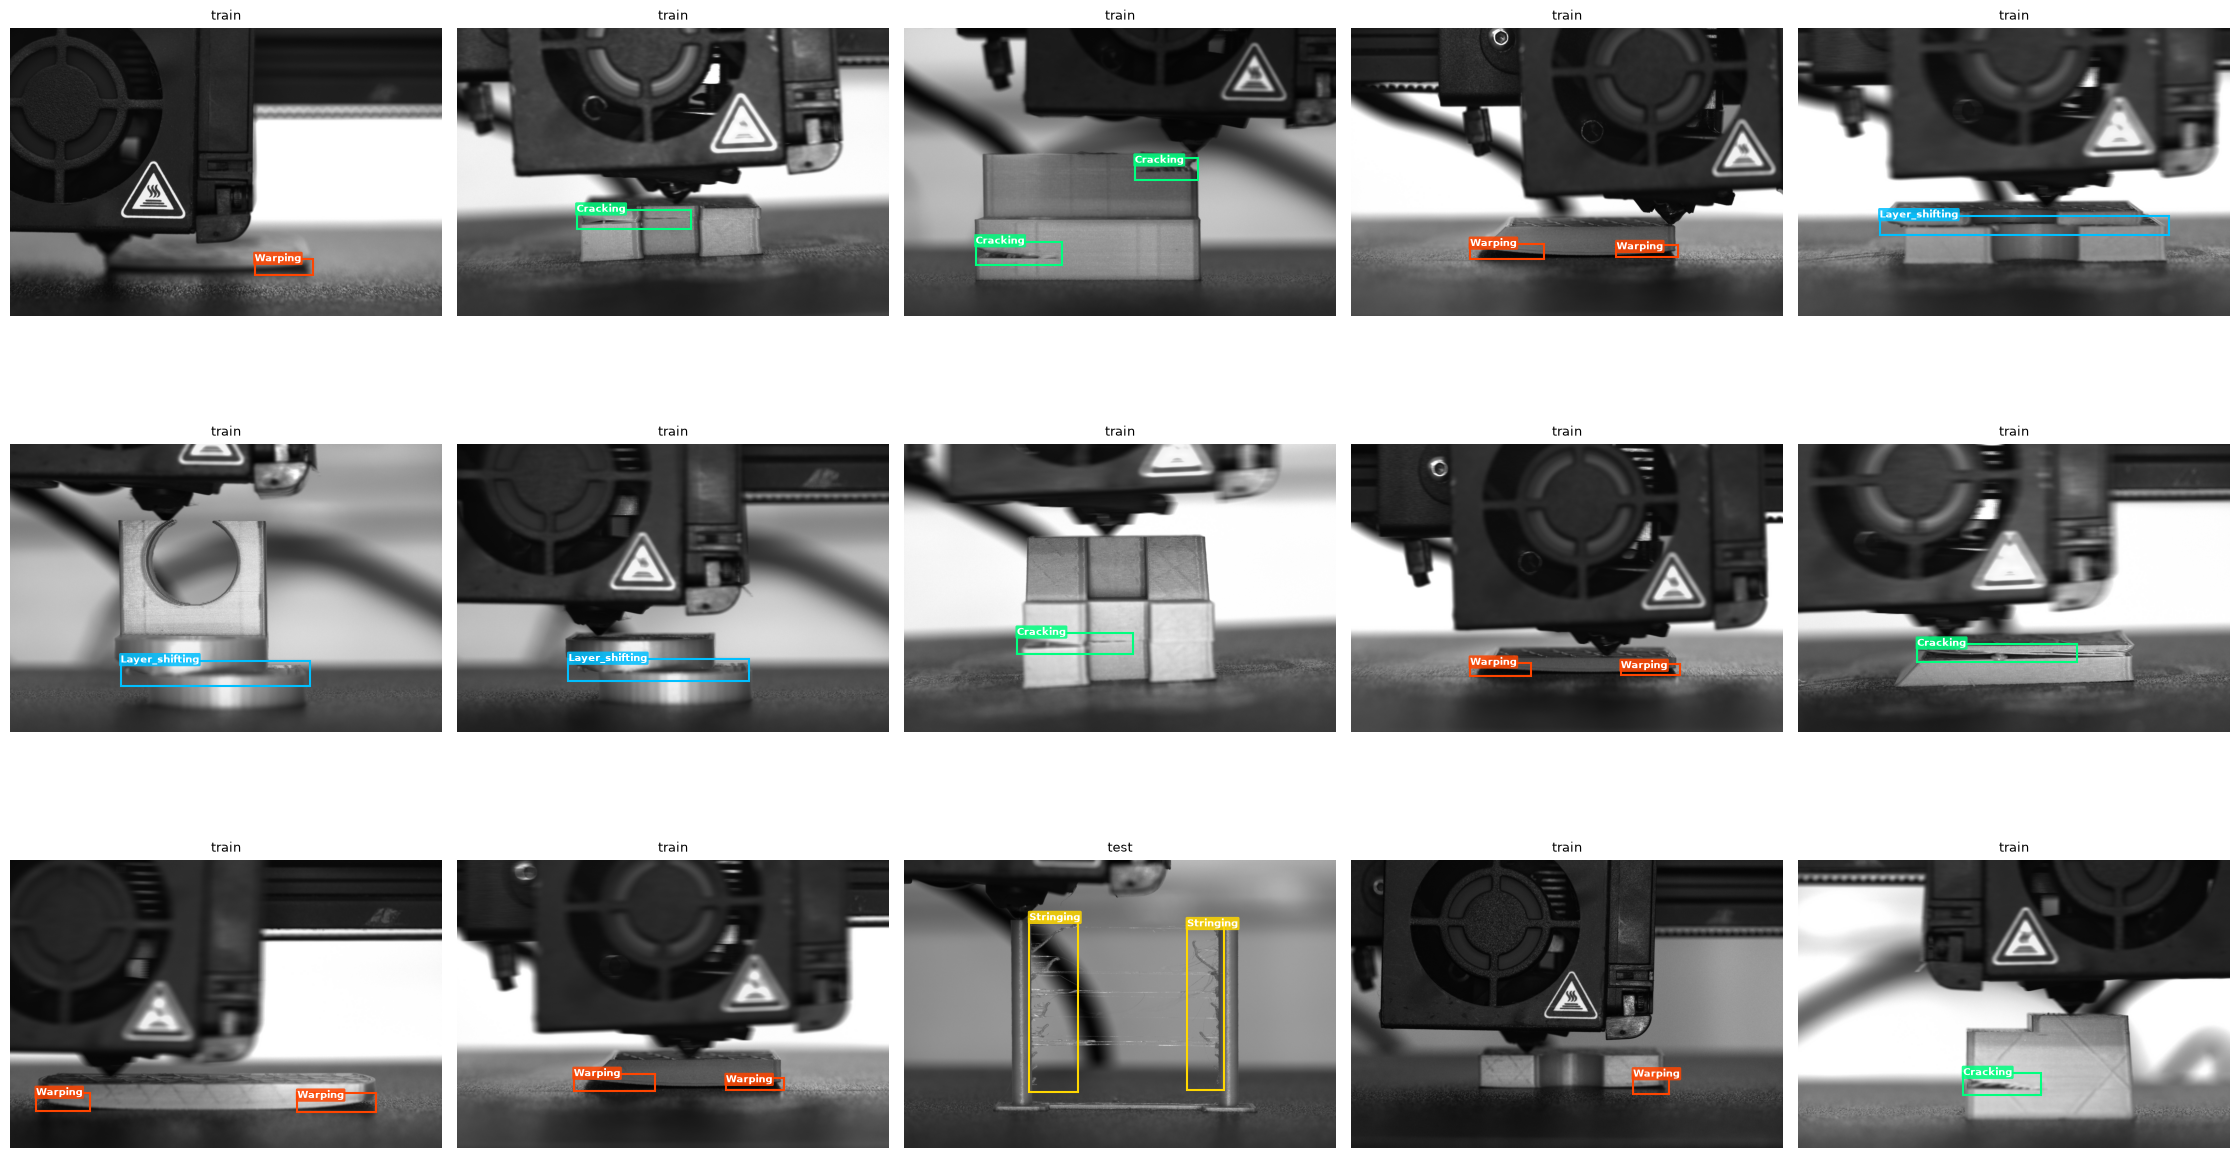

In [5]:
random.seed(42)

pool = []
for split, data in split_data.items():
    split_dir = PROCESSED_DIR / split
    cat_id_to_name = {c["id"]: c["name"] for c in data["categories"]}
    anns_by_image = {}
    for ann in data["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    for img in data["images"]:
        if img["id"] in anns_by_image:
            pool.append((split, split_dir, img, anns_by_image[img["id"]], cat_id_to_name))

sample = random.sample(pool, min(15, len(pool)))
n_cols = 5
n_rows = (len(sample) + n_cols - 1) // n_cols

# Distinct colors per class so labels/boxes are easier to tell apart
CLASS_COLORS = {
    "Cracking": "#00FF7F",       # spring green
    "Layer_shifting": "#00BFFF", # deep sky blue
    "Off_platform": "#FF6EC7",   # pink
    "Stringing": "#FFD700",      # gold
    "Warping": "#FF4500",        # orange red
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))
axes = axes.flatten()

for i, (split, split_dir, img_info, anns, cat_id_to_name) in enumerate(sample):
    img_path = split_dir / "images" / img_info["file_name"]
    if not img_path.exists():
        img_path = split_dir / img_info["file_name"]

    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    ax = axes[i]
    ax.imshow(img)

    # Sort boxes left-to-right so overlapping labels on adjacent boxes
    # (e.g. two "Warping" boxes side by side) get staggered vertically
    anns_sorted = sorted(anns, key=lambda a: a["bbox"][0])

    for j, ann in enumerate(anns_sorted):
        x, y, w, h = ann["bbox"]
        cls_name = cat_id_to_name[ann["category_id"]]
        color = CLASS_COLORS.get(cls_name, "lime")

        rect = patches.Rectangle((x, y), w, h, linewidth=1.5,
                                  edgecolor=color, facecolor="none")
        ax.add_patch(rect)

        # Place label ABOVE the box if there's room, otherwise INSIDE
        # the top of the box (never fully below/off-canvas).
        label_y = y - 8 if y - 8 > 10 else y + 14

        # Stagger alternating boxes vertically to reduce horizontal
        # label collisions when boxes sit side by side
        if j % 2 == 1:
            label_y += 20

        ax.text(x, label_y, cls_name, color="white", fontsize=7,
                 weight="bold", ha="left", va="center",
                 bbox=dict(facecolor=color, edgecolor="none",
                            boxstyle="round,pad=0.15", alpha=0.85))

    ax.set_title(split, fontsize=9)
    ax.axis("off")

for j in range(len(sample), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "sample_annotations.png", dpi=150)
plt.show()

## Summary: our dataset vs. the base paper's dataset

| | Base paper | Ours |
|---|---|---|
| Raw images | 294 | 1867 |
| Post-augmentation train images | 940 (8:1:1 of 1176 total) | see train count above |
| Split ratio | 8:1:1 | 8:1:1 (matched) |
| Classes | 5 (same categories) | 5 (same categories) |
| Class balance | Roughly even (50-72 per class) | Imbalanced (91-538 per class) |
| Augmentation split-leakage | Possible (split after augmenting) | Avoided (grouped by source photo before split) |

**Note:** absolute metric values are not directly comparable to the
paper's Table 3/5 due to dataset differences above. Relative trends
across our own three detectors (YOLOv8, RT-DETR, DINO) remain valid
comparisons.